In [1]:
# import plotly
from pathlib import Path
from matplotlib import pyplot as plt
import pandas as pd
import scanpy as sc
import spatialdata as sd
import spatialdata_plot as sdp
import spatialdata_io as spio
# import squidpy as sq
import anndata as ad
# from napari_spatialdata import Interactive
import matplotlib.patches as patches
import numpy as np
# from stimage2.plots import plot_image_layer_mesh
from PIL import Image
import sopa.io

In [2]:
sdp.__version__

'0.2.4'

In [3]:
sd.__version__

'0.2.2'

In [4]:
import subprocess
system = subprocess.check_output(["hostname", "-s"]).decode("utf-8").strip()
BASE_PATH_ = Path()
if "bun" in system:
    BASE_PATH_ = Path("/QRISdata/Q1851/Xiao/")
elif "imb-quan-gpu" in system:
    BASE_PATH_ = Path("/home/uqxtan9/Q1851/Xiao/")


BASE_PATH = BASE_PATH_ / "Working_project/MB"
DATA_PATH = BASE_PATH / "Xenium_Brain"
XENIUM_RAW_PATH = DATA_PATH / "Xenium_PROCESSED/"
MALDI_RAW_PATH = DATA_PATH / "MALDI_RAW/imzml_file"
# PROCESSED_ = Path("/QRISdata/Q2051/Xiao/Working_project/MB/PROCESSED")
# PROCESSED_ = Path("/home/uqxtan9/Q2051/Xiao/Working_project/MB/PROCESSED")
# PROCESSED_.mkdir(exist_ok=True, parents=True)
PROCESSED = BASE_PATH / "PROCESSED"
PROCESSED.mkdir(exist_ok=True, parents=True)
OUT_PATH = BASE_PATH / "PLOTS" / "Xenium"
# OUT_PATH = Path("/home/uqxtan9/Q2051/Xiao/Working_project/MB/") / "PLOTS" / "Xenium"
OUT_PATH.mkdir(exist_ok=True, parents=True)
# OUT_PATH = BASE_PATH / "PLOTS" / "Xenium"
# OUT_PATH.mkdir(exist_ok=True, parents=True)
QC_PATH = OUT_PATH / "QC"
QC_PATH.mkdir(exist_ok=True, parents=True)
CLS_PATH = OUT_PATH / "CLUSTERING"
CLS_PATH.mkdir(exist_ok=True, parents=True)
CCI_PATH = OUT_PATH / "CCI"
CCI_PATH.mkdir(exist_ok=True, parents=True)

In [5]:
XENIUM_RAW_PATH

PosixPath('/QRISdata/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_PROCESSED')

In [6]:
sample_names_h = [
 'P6055125',
 'P52407',
 'P38685',
 'B59460',
 'P62560']
sample_names_m = [
 'Ctrl_1',
 'Treated_1',
 'Treated_2',
 'Ctrl_2',]

In [ ]:
gene_list = ["FGFR3", "SPON1", "AQP4", "GJA1", "TGFB2", "THBS1", "APOE", "NES", "SOX9", "MEIS2", "PAX6"]

In [11]:
import scipy.stats as stats
import seaborn as sns

# Store PCC results
pcc_results = []

# Helper function to compute PCC and store results
def compute_and_store_pcc(df, library_id, group, astro_col="Astrocyte", genes=["IDH2", "MGST1"]):
    for gene in genes:
        if gene in df.columns:
            pcc, _ = stats.pearsonr(df[astro_col], df[gene])
            pcc_results.append({
                "library_id": library_id,
                "group": group,
                "gene": gene,
                "pcc": pcc
            })

# Plot and calculate PCC for mouse samples
for library_id in sample_names_m:
    file_path = XENIUM_RAW_PATH / library_id
    sdata = spio.xenium(file_path)
    df = sdata["table"].to_df()
    sdata["table"].obs["Astrocyte"] = df.loc[:, gene_list].mean(axis=1)
    fig, ax = plt.subplots()
    sdata.pl.render_shapes("cell_circles", color="Astrocyte").pl.show(ax=ax)
    fig.savefig(f"./{library_id}_Astrocyte.png", bbox_inches='tight', dpi=300)
    plt.close()
    # Compute PCC for Astrocyte vs IDH2 and MGST1
    if "IDH2" in df.columns and "MGST1" in df.columns:
        df["Astrocyte"] = sdata["table"].obs["Astrocyte"]
        compute_and_store_pcc(df, library_id, "mouse")

# Plot and calculate PCC for human samples
for library_id in sample_names_h:
    file_path = XENIUM_RAW_PATH / library_id
    sdata = spio.xenium(file_path)
    df = sdata["table"].to_df()
    sdata["table"].obs["Astrocyte"] = df.loc[:, gene_list].mean(axis=1)
    fig, ax = plt.subplots()
    sdata.pl.render_shapes("cell_circles", color="Astrocyte").pl.show(ax=ax)
    fig.savefig(f"./{library_id}_Astrocyte.png", bbox_inches='tight', dpi=300)
    plt.close()
    # Compute PCC for Astrocyte vs IDH2 and MGST1
    if "IDH2" in df.columns and "MGST1" in df.columns:
        df["Astrocyte"] = sdata["table"].obs["Astrocyte"]
        compute_and_store_pcc(df, library_id, "human")

# Make box plot of PCCs
import pandas as pd
pcc_df = pd.DataFrame(pcc_results)
plt.figure(figsize=(6,4))
sns.boxplot(data=pcc_df, x="gene", y="pcc", hue="group")
plt.title("Pearson Correlation Coefficient (Astrocyte vs Genes)")
plt.ylabel("PCC (Astrocyte vs Gene)")
plt.xlabel("Gene")
plt.tight_layout()
plt.savefig("./Astrocyte_vs_Gene_PCC_boxplot.png", dpi=300)
plt.close()

INFO     reading                                                                                                   
         /QRISdata/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_PROCESSED/Ctrl_1/cell_feature_matrix.h5       


/tmp/ipykernel_1440507/2672226737.py:22: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sdata = spio.xenium(file_path)
/home/uqxtan9/micromamba/envs/stimage2/lib/python3.10/functools.py:926: UserWarning: The index of the dataframe is not monotonic increasing. It is recommended to sort the data to adjust the order of the index before calling .parse() to avoid possible problems due to unknown divisions
  return method.__get__(obj, cls)(*args, **kwargs)
/home/uqxtan9/micromamba/envs/stimage2/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


INFO     Using datashader                                                                                          
INFO     reading                                                                                                   
         /QRISdata/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_PROCESSED/Treated_1/cell_feature_matrix.h5    


/tmp/ipykernel_1440507/2672226737.py:22: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sdata = spio.xenium(file_path)
/home/uqxtan9/micromamba/envs/stimage2/lib/python3.10/functools.py:926: UserWarning: The index of the dataframe is not monotonic increasing. It is recommended to sort the data to adjust the order of the index before calling .parse() to avoid possible problems due to unknown divisions
  return method.__get__(obj, cls)(*args, **kwargs)
/home/uqxtan9/micromamba/envs/stimage2/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


INFO     Using datashader                                                                                          
INFO     reading                                                                                                   
         /QRISdata/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_PROCESSED/Treated_2/cell_feature_matrix.h5    


...

INFO     Using datashader                                                                                          
INFO     reading                                                                                                   
         /QRISdata/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_PROCESSED/B59460/cell_feature_matrix.h5       


/tmp/ipykernel_1440507/2672226737.py:37: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sdata = spio.xenium(file_path)
/home/uqxtan9/micromamba/envs/stimage2/lib/python3.10/functools.py:926: UserWarning: The index of the dataframe is not monotonic increasing. It is recommended to sort the data to adjust the order of the index before calling .parse() to avoid possible problems due to unknown divisions
  return method.__get__(obj, cls)(*args, **kwargs)
/home/uqxtan9/micromamba/envs/stimage2/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


INFO     Using datashader                                                                                          
INFO     reading                                                                                                   
         /QRISdata/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_PROCESSED/P62560/cell_feature_matrix.h5       


/tmp/ipykernel_1440507/2672226737.py:37: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sdata = spio.xenium(file_path)
/home/uqxtan9/micromamba/envs/stimage2/lib/python3.10/functools.py:926: UserWarning: The index of the dataframe is not monotonic increasing. It is recommended to sort the data to adjust the order of the index before calling .parse() to avoid possible problems due to unknown divisions
  return method.__get__(obj, cls)(*args, **kwargs)
/home/uqxtan9/micromamba/envs/stimage2/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


INFO     Using datashader                                                                                          


In [15]:
# Make bar plot of PCCs for every sample, regardless of group
import pandas as pd

pcc_df = pd.DataFrame(pcc_results)

plt.figure(figsize=(10,6))
sns.barplot(data=pcc_df, x="gene", y="pcc", hue="library_id", ci=None)
plt.title("Pearson Correlation Coefficient (Astrocyte vs Genes) by Sample")
plt.ylabel("PCC (Astrocyte vs Gene)")
plt.xlabel("Gene")
plt.legend(title="Sample", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("./Astrocyte_vs_Gene_PCC_barplot_per_sample.png", dpi=300)
plt.close()

In [7]:
sdata_dict = {}
for library_id in sample_names_m:
    file_path = XENIUM_RAW_PATH / library_id
    sdata = spio.xenium(file_path)
    for gene in ["IDH2", "MGST1"]:
        fig, ax = plt.subplots()
        sdata.pl.render_shapes("cell_circles", color=gene).pl.show(ax=ax)
        fig.savefig(f"./{library_id}_{gene}.png", bbox_inches='tight', dpi=300)
        plt.close()

INFO     reading                                                                                                   
         /QRISdata/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_PROCESSED/Ctrl_1/cell_feature_matrix.h5       


/tmp/ipykernel_1440507/3205563776.py:4: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sdata = spio.xenium(file_path)
/home/uqxtan9/micromamba/envs/stimage2/lib/python3.10/functools.py:926: UserWarning: The index of the dataframe is not monotonic increasing. It is recommended to sort the data to adjust the order of the index before calling .parse() to avoid possible problems due to unknown divisions
  return method.__get__(obj, cls)(*args, **kwargs)
/home/uqxtan9/micromamba/envs/stimage2/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


INFO     Using datashader                                                                                          


/home/uqxtan9/micromamba/envs/stimage2/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


INFO     Using datashader                                                                                          
INFO     reading                                                                                                   
         /QRISdata/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_PROCESSED/Treated_1/cell_feature_matrix.h5    


...

INFO     Using datashader                                                                                          
INFO     reading                                                                                                   
         /QRISdata/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_PROCESSED/Ctrl_2/cell_feature_matrix.h5       


/tmp/ipykernel_1440507/3205563776.py:4: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sdata = spio.xenium(file_path)
/home/uqxtan9/micromamba/envs/stimage2/lib/python3.10/functools.py:926: UserWarning: The index of the dataframe is not monotonic increasing. It is recommended to sort the data to adjust the order of the index before calling .parse() to avoid possible problems due to unknown divisions
  return method.__get__(obj, cls)(*args, **kwargs)
/home/uqxtan9/micromamba/envs/stimage2/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


INFO     Using datashader                                                                                          


/home/uqxtan9/micromamba/envs/stimage2/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


INFO     Using datashader                                                                                          


In [16]:
sdata_dict = {}
for library_id in sample_names_h:
    file_path = XENIUM_RAW_PATH / library_id
    sdata = spio.xenium(file_path)
    for gene in ["IDH2", "MGST1"]:
        fig, ax = plt.subplots()
        sdata.pl.render_shapes("cell_circles", color=gene).pl.show(ax=ax)
        fig.savefig(f"./{library_id}_{gene}.png", bbox_inches='tight', dpi=300)
        plt.close()

INFO     reading                                                                                                   
         /QRISdata/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_PROCESSED/P6055125/cell_feature_matrix.h5     


/tmp/ipykernel_1081528/4272196729.py:4: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sdata = spio.xenium(file_path)


INFO     Using datashader                                                                                          


/home/uqxtan9/micromamba/envs/stimage2/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


INFO     Using datashader                                                                                          


...

INFO     Using datashader                                                                                          
INFO     reading                                                                                                   
         /QRISdata/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_PROCESSED/P62560/cell_feature_matrix.h5       


/tmp/ipykernel_1081528/4272196729.py:4: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sdata = spio.xenium(file_path)
/home/uqxtan9/micromamba/envs/stimage2/lib/python3.10/functools.py:926: UserWarning: The index of the dataframe is not monotonic increasing. It is recommended to sort the data to adjust the order of the index before calling .parse() to avoid possible problems due to unknown divisions
  return method.__get__(obj, cls)(*args, **kwargs)
/home/uqxtan9/micromamba/envs/stimage2/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


INFO     Using datashader                                                                                          


/home/uqxtan9/micromamba/envs/stimage2/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


INFO     Using datashader                                                                                          


In [6]:
file_path = XENIUM_RAW_PATH / "B59460"
sdata = spio.xenium(file_path)

INFO     reading                                                                                                   
         /QRISdata/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_PROCESSED/B59460/cell_feature_matrix.h5       


/tmp/ipykernel_2202086/2900115866.py:2: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sdata = spio.xenium(file_path)
/home/uqxtan9/micromamba/envs/stimage2/lib/python3.10/functools.py:926: UserWarning: The index of the dataframe is not monotonic increasing. It is recommended to sort the data to adjust the order of the index before calling .parse() to avoid possible problems due to unknown divisions
  return method.__get__(obj, cls)(*args, **kwargs)


/home/uqxtan9/micromamba/envs/stimage2/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


INFO     Using datashader                                                                                          


NameError: name 'library_id' is not defined

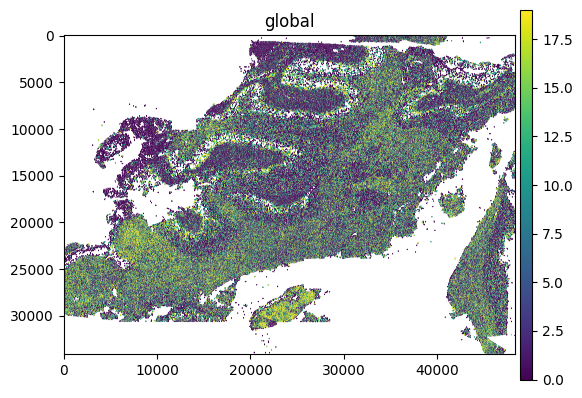

In [7]:

fig, ax = plt.subplots()
sdata.pl.render_shapes("cell_circles", color="IDH2").pl.show(ax=ax)
fig.savefig(f"./{gene}_test.png", bbox_inches='tight', dpi=300)
plt.close()


In [ ]:
sdata_dict = {}
for library_id in sample_names:
    file_path = XENIUM_RAW_PATH / library_id
    # HE_PATH = XENIUM_RAW_PATH / library_id / "morphology_HE_20x.ome.tif"
    # HE_AFFINE_PATH = XENIUM_RAW_PATH / library_id / "Morphology_HE_20x_matrix.csv"
    annotation_df = pd.read_csv(PROCESSED/ f"{library_id}_marker_annotation_tuan.csv", index_col=0)
    sdata = spio.xenium(file_path)
    df_ = sdata.tables["table"].obs
    df_.index = sdata.tables["table"].obs["cell_id"]
    df_["cell_type"] = "Others"
    df_.loc[annotation_df.index,"cell_type"] = annotation_df.loc[:,"cell_type"]
    sdata.tables["table"].obs["cell_type"] = df_["cell_type"]
    sopa.io.write(
        XENIUM_RAW_PATH / library_id,
        sdata,
        image_key="morphology_focus",
        mode="+o",
        ram_threshold_gb=256,
    )
    # HE_align = spio.xenium_aligned_image(HE_PATH, HE_AFFINE_PATH)
    # sdata["HE"] = HE_align
    # sdata_dict[library_id] = sdata
    # sdata.shapes["nucleus_boundaries"]["cell_type"] = sdata.tables["table"].obs["cell_type"].values
    # cat_type = pd.CategoricalDtype(['Oligodendrocyte', 'Astrocyte',
    #               'Microglia', 'Proliferation', 'Cancer cells','Others'], ordered=True)
    # sdata.shapes["nucleus_boundaries"]["cell_type"] = sdata.shapes["nucleus_boundaries"]["cell_type"].astype(cat_type)
    # sdata.tables["table"].obs["region"] = "cell_boundaries"
    # sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")
    # fig, ax = plt.subplots()
    # sdata.pl.render_images(elements="HE", scale="full").pl.render_shapes(
    #     "nucleus_boundaries",
    #     color="cell_type", cmap="tab20"
    #     ).pl.show(ax=ax, title=f"{library_id} Cell Type", coordinate_systems="global")
    # fig.savefig(CELL_TYPE / f"{library_id}_cell_type.png", bbox_inches='tight', dpi=2000)
    # plt.close()
    
    

INFO     reading                                                                                                   
         /home/uqxtan9/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_RAW/P6055125/cell_feature_matrix.h5       


[INFO] (sopa.io.explorer.table) Writing 2 cell categories: region, cell_type
[INFO] (sopa.io.explorer.converter) Saved files in the following directory: /home/uqxtan9/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_RAW/P6055125
[INFO] (sopa.io.explorer.converter) You can open the experiment with 'open /home/uqxtan9/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_RAW/P6055125/experiment.xenium'


INFO     reading /home/uqxtan9/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_RAW/P52407/cell_feature_matrix.h5 


[INFO] (sopa.io.explorer.table) Writing 2 cell categories: region, cell_type
[INFO] (sopa.io.explorer.converter) Saved files in the following directory: /home/uqxtan9/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_RAW/P52407
[INFO] (sopa.io.explorer.converter) You can open the experiment with 'open /home/uqxtan9/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_RAW/P52407/experiment.xenium'


INFO     reading /home/uqxtan9/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_RAW/Ctrl_1/cell_feature_matrix.h5 


...

[INFO] (sopa.io.explorer.table) Writing 2 cell categories: region, cell_type
[INFO] (sopa.io.explorer.converter) Saved files in the following directory: /home/uqxtan9/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_RAW/Ctrl_2
[INFO] (sopa.io.explorer.converter) You can open the experiment with 'open /home/uqxtan9/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_RAW/Ctrl_2/experiment.xenium'


INFO     reading /home/uqxtan9/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_RAW/B59460/cell_feature_matrix.h5 


[INFO] (sopa.io.explorer.table) Writing 2 cell categories: region, cell_type
[INFO] (sopa.io.explorer.converter) Saved files in the following directory: /home/uqxtan9/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_RAW/B59460
[INFO] (sopa.io.explorer.converter) You can open the experiment with 'open /home/uqxtan9/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_RAW/B59460/experiment.xenium'


INFO     reading /home/uqxtan9/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_RAW/P62560/cell_feature_matrix.h5 


[INFO] (sopa.io.explorer.table) Writing 2 cell categories: region, cell_type
[INFO] (sopa.io.explorer.converter) Saved files in the following directory: /home/uqxtan9/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_RAW/P62560
[INFO] (sopa.io.explorer.converter) You can open the experiment with 'open /home/uqxtan9/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_RAW/P62560/experiment.xenium'


In [15]:
for library_id, sdata in sdata_dict.items():
    # sdata.write(PROCESSED_ / f"niche_{library_id}.zarr")
    # sdata.write(f"/scratch/project_mnt/S0010/Xiao/skin_codex/niche_{library_id}.zarr")
    sopa.io.write(
        PROCESSED_ / f"explorer/processed_{library_id}.explorer",
        sdata,
        image_key="morphology_focus",
        mode="+o",
        ram_threshold_gb=256,
    )

[INFO] (sopa.io.explorer.table) Writing 2 cell categories: region, cell_type
[INFO] (sopa.io.explorer.converter) Saved files in the following directory: /scratch/project_mnt/S0010/Xiao/Q2051/Xiao/Working_project/MB/PROCESSED/processed_Ctrl_1.explorer
[INFO] (sopa.io.explorer.converter) You can open the experiment with 'open /scratch/project_mnt/S0010/Xiao/Q2051/Xiao/Working_project/MB/PROCESSED/processed_Ctrl_1.explorer/experiment.xenium'
[INFO] (sopa.io.explorer.table) Writing 2 cell categories: region, cell_type
[INFO] (sopa.io.explorer.converter) Saved files in the following directory: /scratch/project_mnt/S0010/Xiao/Q2051/Xiao/Working_project/MB/PROCESSED/processed_Ctrl_2.explorer
[INFO] (sopa.io.explorer.converter) You can open the experiment with 'open /scratch/project_mnt/S0010/Xiao/Q2051/Xiao/Working_project/MB/PROCESSED/processed_Ctrl_2.explorer/experiment.xenium'
[INFO] (sopa.io.explorer.table) Writing 2 cell categories: region, cell_type
[INFO] (sopa.io.explorer.converter) S

[INFO] (sopa.io.explorer.table) Writing 2 cell categories: region, cell_type
[INFO] (sopa.io.explorer.converter) Saved files in the following directory: /scratch/project_mnt/S0010/Xiao/Q2051/Xiao/Working_project/MB/PROCESSED/processed_Treated_2.explorer
[INFO] (sopa.io.explorer.converter) You can open the experiment with 'open /scratch/project_mnt/S0010/Xiao/Q2051/Xiao/Working_project/MB/PROCESSED/processed_Treated_2.explorer/experiment.xenium'


In [24]:
test = sdata["transcripts"].compute()

In [30]:
test

,x,y,z,feature_name,cell_id,fov_name,overlaps_nucleus,transcript_id,qv,nucleus_distance
0,23.212183,163.522964,12.129123,CCNB2,UNASSIGNED,B4,0,281505041482829,11.107392,377.359711
1,24.320675,64.803810,12.030653,THEMIS,UNASSIGNED,B4,0,281505041482830,40.000000,450.131287
2,30.356863,47.203968,12.097727,SNTB2,UNASSIGNED,B4,0,281505041482832,40.000000,460.698242
3,84.834915,88.692429,12.100723,CCNB2,UNASSIGNED,B4,0,281505041482843,40.000000,395.802612
4,99.909622,183.406052,12.059742,FCER1G,UNASSIGNED,B4,0,281505041482844,40.000000,310.242737
...,...,...,...,...,...,...,...,...,...,...
1381412,7821.320312,2799.826660,21.410124,SOX4,UNASSIGNED,E16,0,281668250345178,38.893162,414.255249
1381413,7815.033691,2836.148438,21.380888,UnassignedCodeword_0461,UNASSIGNED,E16,0,281668250348163,9.122305,408.191437
1381414,7774.964844,2769.338623,21.331158,PAX6,UNASSIGNED,E16,0,281668250350446,30.107880,364.155762
1381415,7799.248047,2852.615479,21.364153,TGFB2,UNASSIGNED,E16,0,281668250356232,20.259678,392.431061
